In [142]:
font_path = "../fonts/字悦九叠印篆.ttf"

实际宽度(像素): 44, 高度(像素): 45, 每行字节数(Pitch): 6


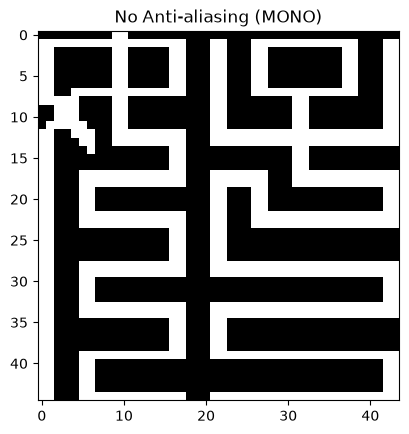

In [143]:
import freetype
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载字体文件
face = freetype.Face(font_path)

# 2. 设置字符大小
face.set_pixel_sizes(49, 0)

# 3. 加载字符（强制单色无抗锯齿）
flags = freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_MONO
face.load_char("好", flags)

# 4. 获取位图和关键维度
bitmap = face.glyph.bitmap
width = bitmap.width
rows = bitmap.rows
pitch = bitmap.pitch  # 核心：每一行实际占用的字节数

print(f"实际宽度(像素): {width}, 高度(像素): {rows}, 每行字节数(Pitch): {pitch}")

# 5. 正确解析底层 Buffer
# 首先将 buffer 转为常规的 uint8 字节数组
buffer_array = np.frombuffer(bytes(bitmap.buffer), dtype=np.uint8)

# 检查是否有有效像素，防止空白字符（如空格）导致 reshape 报错
if rows > 0 and width > 0:
    # 核心步骤：将字节数组 reshape 成 (行数, 每行字节数)
    # 然后用 unpackbits 将每个字节拆解为 8 个 0 或 1 的比特流
    bits = np.unpackbits(buffer_array).reshape(rows, pitch * 8)

    # 因为字节对齐原因，右侧可能会有多余的补零 bits，需要裁剪到实际的宽度
    img_array = bits[:, :width]

    # 为了让 matplotlib 更好看，我们可以把 1 变成 255（白色），0 保持黑色
    img_array = img_array * 255

    # 6. 用 matplotlib 显示
    plt.imshow(img_array, cmap="gray")
    plt.title("No Anti-aliasing (MONO)")
    plt.show()

    # 7. 如果你想转成 PIL Image 保存
    img = Image.fromarray(img_array.astype(np.uint8), mode="L")
    img.save("output_mono.png")
else:
    print("该字符没有产生有效的位图（可能是空格）。")

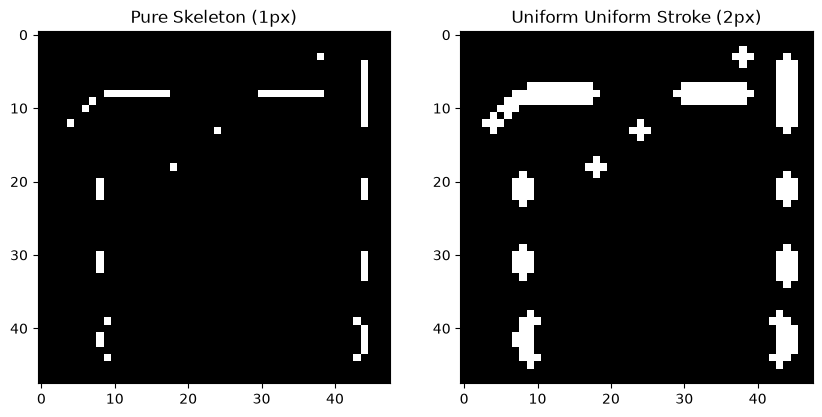

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from skimage.morphology import skeletonize
from skimage.transform import resize

# 1. 极高分辨率渲染（获取平滑的矢量形态）
high_res = 512
font = ImageFont.truetype(font_path, high_res)
img = Image.new("L", (high_res, high_res), 0)
draw = ImageDraw.Draw(img)
draw.text((0, 0), "好", fill=255, font=font)
binary_img = np.array(img) > 127

# 2. 提取绝对中心的单像素骨架
skeleton = skeletonize(binary_img)

# 3. 下采样到你目标的小像素尺寸 (例如 48x48)
target_size = (48, 48)
# 使用 max pooling 思想或内插，保留骨架连通性
pixel_skeleton = resize(skeleton, target_size, order=0) > 0.1

# 4. 强制指定笔画粗细 (使用形态学膨胀)
# 如果你想要笔画粗细为 1 像素，直接用 pixel_skeleton 即可
# 如果想要 2 像素或更粗，可以用 scipy.ndimage.binary_dilation
from scipy.ndimage import binary_dilation

pixel_stroke_1 = pixel_skeleton  # 1像素均匀粗细
pixel_stroke_2 = binary_dilation(pixel_skeleton)  # 2像素均匀粗细

# 可视化对比
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Pure Skeleton (1px)")
plt.imshow(pixel_stroke_1, cmap="gray")
plt.subplot(122)
plt.title("Uniform Uniform Stroke (2px)")
plt.imshow(pixel_stroke_2, cmap="gray")
plt.show()

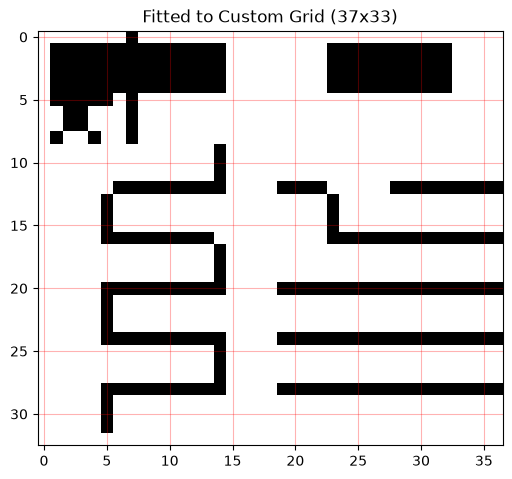

In [ ]:
import freetype
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union


def get_vector_outlines(font_path, char):
    """从 FreeType 中提取字符的绝对矢量多边形"""
    face = freetype.Face(font_path)
    face.set_char_size(1000 * 64)  # 使用极高精度的矢量缩放
    face.load_char(char, freetype.FT_LOAD_NO_BITMAP)

    outline = face.glyph.outline
    points = np.array(outline.points)
    contours = outline.contours
    tags = outline.tags

    polygons = []
    start = 0
    for end in contours:
        contour_pts = points[start : end + 1]
        start = end + 1

        # 简化处理：九叠篆等字体大部分是直线。这里直接视作多边形顶点
        # 如果有贝塞尔曲线，完美做法是根据 tags 进行插值采样，这里简化为闭合多边形
        if len(contour_pts) >= 3:
            poly = Polygon(contour_pts)
            if not poly.is_valid:
                poly = poly.buffer(0)  # 修复自交的无效多边形
            polygons.append(poly)

    # 合并内外轮廓（处理“口”、“日”字等镂空情况）
    # 奇偶规则：利用 unary_union 或 sym_difference
    glyph_shape = unary_union(polygons)
    return glyph_shape


def fit_to_custom_grid(glyph_shape, grid_width, grid_height):
    """将矢量轮廓缩放并拟合到自定义的网格矩阵中"""
    # 1. 获取字体的绝对边界 (Bounding Box)
    minx, miny, maxx, maxy = glyph_shape.bounds
    w, h = maxx - minx, maxy - miny

    # 2. 创建自定义网格的画布 (初始化为全0)
    grid = np.zeros((grid_height, grid_width), dtype=np.uint8)

    # 3. 遍历自定义网格的每一个像素中心点
    for r in range(grid_height):
        for c in range(grid_width):
            # 将网格坐标 (c, r) 映射回字体的矢量坐标空间
            # 翻转 y 轴，因为屏幕坐标系（左上角0,0）与字体坐标系（左下角0,0）相反
            norm_x = c / grid_width
            norm_y = (grid_height - 1 - r) / grid_height

            vector_x = minx + norm_x * w
            vector_y = miny + norm_y * h

            # 创建物理采样的中心点
            point = Point(vector_x, vector_y)

            # 4. 核心拟合逻辑：判断该网格中心点是否在矢量轮廓内部
            if glyph_shape.contains(point):
                grid[r, c] = 1

    return grid


# ==================== 测试运行 ====================
font_path = font_path

# 1. 获取纯矢量形状
glyph_shape = get_vector_outlines(font_path, "好")

# 2. 自由定义你的物理网格规格 (例如：53x49，或者任意非对称、稀疏网格)
CUSTOM_WIDTH = 37
CUSTOM_HEIGHT = 33

grid_result = fit_to_custom_grid(glyph_shape, CUSTOM_WIDTH, CUSTOM_HEIGHT)

# 3. 渲染结果
plt.figure(figsize=(6, 6))
plt.imshow(grid_result, cmap="gray_r", origin="upper")
plt.title(f"Fitted to Custom Grid ({CUSTOM_WIDTH}x{CUSTOM_HEIGHT})")
plt.grid(True, color="red", alpha=0.3, linestyle="-")  # 显式画出你的自定义网格线
plt.show()

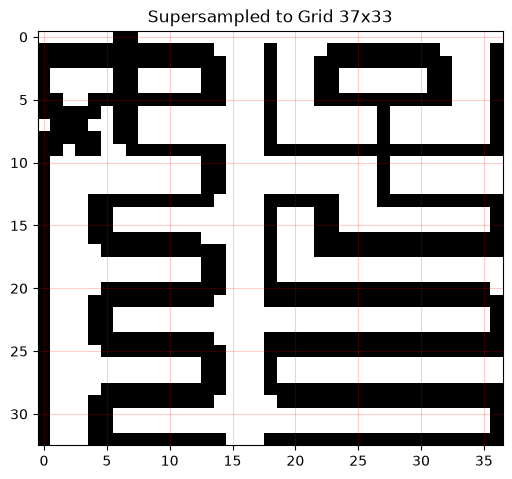

In [ ]:
import freetype
import numpy as np
import matplotlib.pyplot as plt


def get_high_res_bitmap(font_path, char, high_res_size=1024):
    """1. 让 FreeType 渲染出一个超级大的二值化大图"""
    face = freetype.Face(font_path)
    # 强制将像素高度设为极大值
    face.set_pixel_sizes(0, high_res_size)

    flags = freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_MONO
    face.load_char(char, flags)

    bitmap = face.glyph.bitmap
    width, rows, pitch = bitmap.width, bitmap.rows, bitmap.pitch

    if rows == 0 or width == 0:
        return np.zeros((1, 1), dtype=np.uint8)

    # 解包单色位图
    buffer_array = np.frombuffer(bytes(bitmap.buffer), dtype=np.uint8)
    bits = np.unpackbits(buffer_array).reshape(rows, pitch * 8)
    return bits[:, :width]


def fit_via_supersampling(high_res_img, grid_width, grid_height, threshold=0.4):
    """2. 将大图的像素映射并过滤到你的自定义物理网格上"""
    hr_rows, hr_cols = high_res_img.shape

    # 初始化你的自定义物理网格
    custom_grid = np.zeros((grid_height, grid_width), dtype=np.uint8)

    # 计算每个自定义网格格子在大图上对应的步长
    row_step = hr_rows / grid_height
    col_step = hr_cols / grid_width

    for r in range(grid_height):
        for c in range(grid_width):
            # 计算当前网格格子在大图中的像素边界坐标
            r_start = int(r * row_step)
            r_end = max(int((r + 1) * row_step), r_start + 1)
            c_start = int(c * col_step)
            c_end = max(int((c + 1) * col_step), c_start + 1)

            # 提取大图中对应的这个“像素窗口”
            sub_window = high_res_img[r_start:r_end, c_start:c_end]

            # 核心填充逻辑：
            # 方案 A：只看中心点（你说的像素值判断） -> high_res_img[int((r+0.5)*row_step), int((c+0.5)*col_step)]
            # 方案 B（更推荐）：计算这个格子里的覆盖率，超过阈值则填充，能有效防止极细线条丢失
            coverage = np.mean(sub_window)

            if coverage >= threshold:
                custom_grid[r, c] = 1

    return custom_grid


# ==================== 运行测试 ====================
font_path = font_path

# 1. 拿到巨幅黑白图 (1024 像素高)
high_res_img = get_high_res_bitmap(font_path, "好", high_res_size=37 * 33)

# 2. 直接映射到你的自定义 53x49 网格
CUSTOM_WIDTH = 37
CUSTOM_HEIGHT = 33
# threshold 可以微调：越小字越粗（更容易触发填充），越大字越细
grid_result = fit_via_supersampling(
    high_res_img, CUSTOM_WIDTH, CUSTOM_HEIGHT, threshold=0.1
)

# 3. 绘图观察
plt.figure(figsize=(6, 6))
plt.imshow(grid_result, cmap="gray_r")
plt.grid(True, color="red", alpha=0.2)
plt.title(f"Supersampled to Grid {CUSTOM_WIDTH}x{CUSTOM_HEIGHT}")
plt.show()

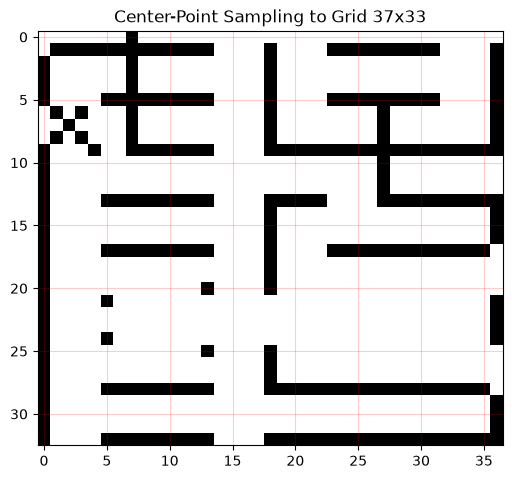

In [ ]:
import freetype
import numpy as np
import matplotlib.pyplot as plt


def get_high_res_bitmap(font_path, char, high_res_size=2048):
    """让 FreeType 渲染出一个极大的二值化大图（这里用 2048 分辨率，中心点采样更精准）"""
    face = freetype.Face(font_path)
    face.set_pixel_sizes(0, high_res_size)

    flags = freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_MONO
    face.load_char(char, flags)

    bitmap = face.glyph.bitmap
    width, rows, pitch = bitmap.width, bitmap.rows, bitmap.pitch

    if rows == 0 or width == 0:
        return np.zeros((1, 1), dtype=np.uint8)

    # 解包单色位图为 0 和 1 的矩阵
    buffer_array = np.frombuffer(bytes(bitmap.buffer), dtype=np.uint8)
    bits = np.unpackbits(buffer_array).reshape(rows, pitch * 8)
    return bits[:, :width]


def fit_via_center_point(high_res_img, grid_width, grid_height):
    """核心：计算每个网格格子的中心点，直接映射并读取大图的像素值"""
    hr_rows, hr_cols = high_res_img.shape

    # 初始化你的自定义物理网格
    custom_grid = np.zeros((grid_height, grid_width), dtype=np.uint8)

    # 计算每个小格子在大图中所占的步长
    row_step = hr_rows / grid_height
    col_step = hr_cols / grid_width

    for r in range(grid_height):
        for c in range(grid_width):
            # 计算当前格子的绝对中心点在大图上的坐标
            center_r = int((r + 0.5) * row_step)
            center_c = int((c + 0.5) * col_step)

            # 边界安全检查，防止浮点数计算后越界
            center_r = min(center_r, hr_rows - 1)
            center_c = min(center_c, hr_cols - 1)

            # 直接读取中心点的像素值（1 或 0）
            custom_grid[r, c] = high_res_img[center_r, center_c]

    return custom_grid


# ==================== 运行测试 ====================
font_path = font_path

# 1. 获取巨幅黑白图（分辨率越高，映射时中心点的坐标就越接近矢量的真实位置）
high_res_img = get_high_res_bitmap(font_path, "好", high_res_size=2048)

# 2. 精准中心点采样映射到 53x49 网格
CUSTOM_WIDTH = 37
CUSTOM_HEIGHT = 33
grid_result = fit_via_center_point(high_res_img, CUSTOM_WIDTH, CUSTOM_HEIGHT)

# 3. 绘图观察
plt.figure(figsize=(6, 6))
plt.imshow(grid_result, cmap="gray_r")
plt.grid(True, color="red", alpha=0.2)
plt.title(f"Center-Point Sampling to Grid {CUSTOM_WIDTH}x{CUSTOM_HEIGHT}")
plt.show()

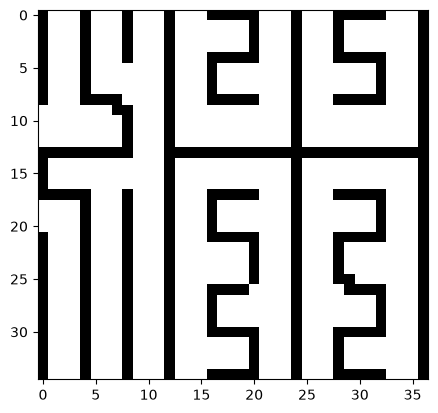

In [154]:
import freetype
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize


def get_perfect_pixel_font(font_path, char, grid_w=53, grid_h=49):
    # 1. 用极高的分辨率渲染，抹平一切栅格化误差
    face = freetype.Face(font_path)
    face.set_pixel_sizes(0, 2048)
    face.load_char(char, freetype.FT_LOAD_RENDER | freetype.FT_LOAD_TARGET_MONO)

    # 2. 转换为 0/1 矩阵
    bitmap = face.glyph.bitmap
    buffer_array = np.frombuffer(bytes(bitmap.buffer), dtype=np.uint8)
    high_res_img = np.unpackbits(buffer_array).reshape(bitmap.rows, bitmap.pitch * 8)[
        :, : bitmap.width
    ]

    # 3. 核心：提取纯粹的、单像素宽度的中心骨架
    # 这相当于在像素层面把“闭合轮廓”强行剥离成了“SVG中心线”
    skeleton = skeletonize(high_res_img > 0)

    # 4. 精准对齐：计算目标网格在骨架图上的采样区域，使用“最大值”而不是单点
    # 只要目标网格像素所对应的超大图区域内碰到了“骨架线”，就激活
    custom_grid = np.zeros((grid_h, grid_w), dtype=np.uint8)
    row_step = skeleton.shape[0] / grid_h
    col_step = skeleton.shape[1] / grid_w

    for r in range(grid_h):
        for c in range(grid_w):
            r_start, r_end = (
                int(r * row_step),
                max(int((r + 1) * row_step), int(r * row_step) + 1),
            )
            c_start, c_end = (
                int(c * col_step),
                max(int((c + 1) * col_step), int(c * col_step) + 1),
            )

            # 如果这个物理格子的范围内有骨架线经过
            if np.any(skeleton[r_start:r_end, c_start:c_end]):
                custom_grid[r, c] = 1

    return custom_grid


# 测试九叠篆
grid_result = get_perfect_pixel_font(font_path, "渊", 37, 33 + 2)
plt.imshow(grid_result, cmap="gray_r")
plt.show()

In [152]:
ord("爽")

29245